# Letterboxd: Social Film Data

### Spring 2026 Data Science Project 
##### Katelyn Hertz

<table cellspacing="0" cellpadding="0" border="0">
  <tr>
    <td style="text-align: center;">
      <img src="img/tp_story_1.gif" alt="GIF 1" width="600" />
    </td>
    <td style="text-align: center;">
      <img src="img/tp_story_3.gif" alt="GIF 2" width="600" />
    </td>
  </tr>
  <tr>
    <td style="text-align: center;">
      <img src="img/tp_story_4.gif" alt="GIF 3" width="600" />
    </td>
    <td style="text-align: center;">
      <img src="img/tp_story_2.gif" alt="GIF 4" width="600" />
    </td>
  </tr>
</table>

## Introduction

Everyone loves movies! And mostly everyone enjoys talking about what they love too. For Internet users who are especially into both, [Letterboxd](https://letterboxd.com/) seems to be the platform of choice. Over the past decade, Letterboxd has become one of the most influential online communities for film discussions and movie discovery. Users can rate, review, and catalog movies they watch, creating large amounts of behavioral data related to film preferences and engagement.

In this project, I have analyzed a large-scale Letterboxd movie ratings dataset collected from publicly accessible user profiles. The dataset contains user ratings, movie metadata, and genre information enriched using data from TMDB. I used this data to investigate patterns in user rating behavior, genre popularity, and movie preferences across thousands of users.

My analysis focuses on three primary questions:

1. Which movie genres receive the most engagement and highest ratings from users?
2. How does user activity relate to rating behavior and genre preference?
3. Can user rating behavior be used to predict a user’s favorite movie genre?

But why are these questions important?

Online movie platforms and advertisements increasingly rely on behavioral data to understand audience preferences, recommend content, and personalize user experiences. Understanding how users interact with movies and genres can help provide insight into viewing trends on a wider scale, and also the potential challenges of predicting one's taste in movies from behavioral data alone.

To answer these questions, I first performed exploratory data analysis and statistical testing to identify relationships between user activity and genre preference. I then applied a machine learning classification model to determine whether user behavior features like review frequency, average rating behavior, and rating variability could predict a user’s favorite genre. Finally, I have visualized and interpreted the strengths and limitations of the resulting model.

##### one more thing...

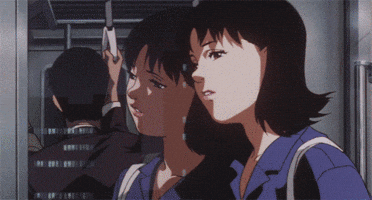

Before we start, think about how you would evaluate a movie. What goes into the decision when you say "that was really good"? Are there certain aspects of a film that tend to disappoint you? In movies we see reflections of our lives, places very different from the ones we know but also strangely close; in characters, we see people we have known or even the person we might like to be... 

At least for me, reviewing a movie is a complicated process and it can be pretty hard to decide what I like. Do you feel that your experience can be captured by a 5-star rating system and a paragraph box alone? 

## Data Curation

My primary dataset was obtained from the Kaggle dataset “Letterboxd Movie Ratings Data” by Sam Learner:

https://www.kaggle.com/datasets/samlearner/letterboxd-movie-ratings-data/data?select=movie_data.csv

The dataset consists of publicly accessible ratings scraped from Letterboxd users and includes three primary tables:

- movie metadata 
- user rating data
- user information

According to the dataset description, the ratings were collected from highly active Letterboxd users, and movie metadata was enriched using the TMDB API.
I chose this dataset because it was information-rich, publicly available, and already had the 3 main types of information separated into CSV files. This made it easy to parse them into dataframes and create additional relationships as needed.

### Data preprocessing and cleaning 

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 

##### initialize dataframes 

In [2]:
movies = pd.read_csv('movie_data.csv',engine='python')
movies.head(5)

,_id,genres,image_url,imdb_id,imdb_link,movie_id,movie_title,original_language,overview,popularity,production_countries,release_date,runtime,spoken_languages,tmdb_id,tmdb_link,vote_average,vote_count,year_released
0,5fc85f606758f69634496fd3,"[""Music"",""Animation""]",film-poster/4/6/4/4/4/0/464440-football-freaks...,NaN,NaN,football-freaks,Football Freaks,en,"Football crazy, football mad. Don’t watch this...",0.600,"[""United Kingdom""]",1971-12-05,0.0,[],535272.0,https://www.themoviedb.org/movie/535272/,0.0,0.0,1971.0
1,5fc85ff26758f696344ace0c,[],film-poster/2/4/5/5/0/0/245500-aftermath-0-230...,tt0586129,http://www.imdb.com/title/tt0586129/maindetails,aftermath-1960,Aftermath,en,Aftermath was the pilot for an unsold TV serie...,0.600,[],1960-04-17,22.0,[],318331.0,https://www.themoviedb.org/movie/318331/,8.0,1.0,1960.0
2,5fc85f606758f69634496fcd,"[""Drama""]",film-poster/9/3/3/1/8/93318-where-chimneys-are...,tt0045731,http://www.imdb.com/title/tt0045731/maindetails,where-chimneys-are-seen,Where Chimneys Are Seen,ja,Gosho’s most celebrated film both in Japan and...,1.568,"[""Japan""]",1953-03-05,108.0,"[""日本語""]",117779.0,https://www.themoviedb.org/movie/117779/,6.6,10.0,1953.0
3,5fc85f606758f69634496fd1,"[""Drama""]",NaN,tt0187327,http://www.imdb.com/title/tt0187327/maindetails,the-musicians-daughter,The Musician's Daughter,en,Carl Wagner's good wife was dying. His heart b...,0.600,"[""United States of America""]",1911-12-12,15.0,[],560377.0,https://www.themoviedb.org/movie/560377/,0.0,0.0,1911.0
4,5fc85f606758f69634496fd4,"[""Documentary""]",film-poster/4/5/4/6/0/3/454603-50-years-of-fab...,tt4769914,http://www.imdb.com/title/tt4769914/maindetails,50-years-of-fabulous,50 Years of Fabulous,en,50 Years of Fabulous recounts the rich history...,0.600,[],2018-05-17,75.0,[],525187.0,https://www.themoviedb.org/movie/525187/,0.0,0.0,2018.0


In [3]:
ratings = pd.read_csv('ratings_export.csv',engine='python')
ratings.head(5) 

,_id,movie_id,rating_val,user_id
0,5fc57c5d6758f6963451a07f,feast-2014,7,deathproof
1,5fc57c5d6758f6963451a063,loving-2016,7,deathproof
2,5fc57c5d6758f6963451a0ef,scripted-content,7,deathproof
3,5fc57c5d6758f6963451a060,the-future,4,deathproof
4,5fc57c5c6758f69634519398,mank,5,deathproof


In [4]:
users = pd.read_csv('users_export.csv',engine='python')
users.head(5) 

,_id,display_name,num_ratings_pages,num_reviews,username
0,5fc4172ec6cd28ebd99dd0e2,Lucy,32.0,1650,deathproof
1,5fc4172ec6cd28ebd99dd0ea,Matt Singer,52.0,1915,superpulse
2,5fc4172ec6cd28ebd99dd0ed,Sean Baker,21.0,1283,lilfilm
3,5fc4172ec6cd28ebd99dd0ee,iana,37.0,1177,ianamurray
4,5fc419171ebf67b9fbe48615,Lizzy,57.0,1810,punchdrunklizzy


## Exploratory Data Analysis

##### check the shape, info, and value counts of each dataframe 

In [5]:
dataframes = [users,movies,ratings]
for df in dataframes:
    print(df.shape)
    print(df.info())
    print(df.count())
    print()

(8139, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8139 entries, 0 to 8138
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   _id                8139 non-null   object 
 1   display_name       7832 non-null   object 
 2   num_ratings_pages  4747 non-null   float64
 3   num_reviews        8139 non-null   int64  
 4   username           8139 non-null   object 
dtypes: float64(1), int64(1), object(3)
memory usage: 318.1+ KB
None
_id                  8139
display_name         7832
num_ratings_pages    4747
num_reviews          8139
username             8139
dtype: int64

(285963, 19)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 285963 entries, 0 to 285962
Data columns (total 19 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   _id                   285963 non-null  object 
 1   genres                274986 non-null  object 
 2 

As seen above, the users dataset contains attributes:
- id: unique identifier for each user
- display_name: title name on profile like "Katelyn" (lol)
- num_ratings_pages: number of film "ratings" (writing something in text box for a logged film)
- num_reviews: number of film "reviews" (selecting something on the scale to 0-5 stars, where the step is 1/2 star)
- username: self-explanatory

The movies dataset includes attributes such as:
- movie_id: unique identifier for each movie 
- movie_title
- genres
- popularity 
- vote_average 
- spoken_languages
- year_released

And the ratings dataset included:
- id: unique identifier for each rating
- movie_id 
- rating_val (on Letterboxd)
- user_id

### Even more data preparation...

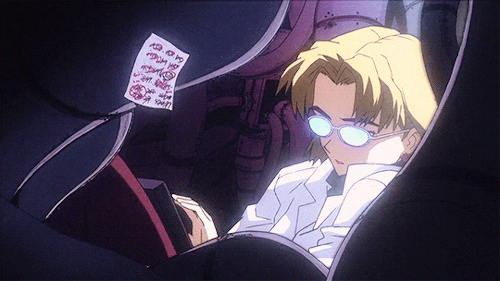

In [6]:
users['num_reviews'] # want to explore relationship between users and reviews!

0       1650
1       1915
2       1283
3       1177
4       1810
        ... 
8134     237
8135     297
8136    1231
8137     800
8138    1901
Name: num_reviews, Length: 8139, dtype: int64

##### create user-level summary table from ratings data 

In [7]:
user_ratings = ratings.groupby('user_id').agg({
    'rating_val': ['mean', 'count', 'min', 'max']
}).reset_index()
user_ratings # is rating_val related to num_reviews?

user_id rating_val              
                           mean count min max
0     007filmreviwer   6.637985  2243   1  10
1     007hertzrumble   6.855283  1997   1  10
2           0o0o0o0o   6.290000   100   1  10
3           11122001   6.120000   325   1  10
4             127gbh   6.954180  1615   1  10
...              ...        ...   ...  ..  ..
7472  zwangsdemokrat   5.205327  1802   1  10
7473   zwergimbikini   6.040724  2210   1  10
7474           zxols   8.170213   376   1  10
7475            zxvs   7.515371   553   3  10
7476           zyopy   7.076050  2643   1  10

[7477 rows x 5 columns]

user_ratings groups the ratings by user_id, so each row represents one user instead of one individual rating. For each user, I calculated their average rating, total number of ratings, minimum rating, and maximum rating. The count of rating_val is equivalent to the number of reviews or ratings submitted by that user, so I later renamed it to num_reviews.

##### also, a movie-level summary table would be useful:

In [8]:
movie_ratings = ratings.groupby(['movie_id']).agg({
    'rating_val': ['mean', 'count', 'min', 'max']
}).reset_index()
movie_ratings

movie_id rating_val              
                                                      mean count min max
0                             0-uhr-15-zimmer-9   5.000000     2   5   5
1                                         00-00   3.000000     3   1   7
2                                         00-08   5.631579    19   1   9
3       00-schneider-im-wendekreis-der-eidechse   6.733333    15   1   9
4            00-schneider-jagd-auf-nihil-baxter   6.080000    25   1  10
...                                         ...        ...   ...  ..  ..
286065             zz-top-live-at-bonnaroo-2013   6.666667     3   6   8
286066             zz-top-live-at-montreux-2013   8.333333     3   6  10
286067                   zz-top-live-from-texas   7.333333     3   6   8
286068              zz-top-live-in-germany-1980   7.000000     2   7   7
286069    zz-top-that-little-ol-band-from-texas   7.136364    44   5   9

[286070 rows x 5 columns]

This does the same type of aggregation but by movie_id. Each row represents one movie, with its average user rating, number of ratings, minimum rating, and maximum rating. I then renamed the columns and merged the average movie rating back into the main movies DataFrame, as seen below:

In [9]:
movie_ratings.columns = ['movie_id', 'avg_rating', 'count', 'min', 'max']
movies = movies.merge(movie_ratings[['movie_id', 'avg_rating']], on='movie_id', how='inner')

This allowed the movie metadata table to include rating information from the ratings table. It's nice to keep things organized!

#### Genre parsing and expansion

The genres column in the movie dataset was stored as a string that looked like a list, such as:

In [10]:
'["Drama", "Comedy"]'

'["Drama", "Comedy"]'

However, Python would still treat this as a string, not an actual list. To fix this, I used ast.literal_eval():

In [11]:
import ast
# prepare for splitting up genres list into one genre per row
movies['genres'] = movies['genres'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else [])

This converted the string representation into an actual Python list. This was necessary because many movies belong to multiple genres.

Next I created a new version of the movies DataFrame where each row contains only one genre. This made it possible to group and analyze ratings by individual genre:

In [12]:
# want a version of movies where each row is only one genre 
movies_exploded = movies.explode('genres')

##### joining movies and ratings by genre

After exploding the genres I wanted to merge the movie data with the ratings data to produce a dataframe where each row connects a user's rating to a specific movie genre. This was useful since the original ratings table only contained movie_id, and none of the other metadata like genre information. This made it easier to analyze things like how many ratings each genre received, what the average rating was for each genre...

In [13]:
# join datasets so we can get ratings per genre 
genre_ratings = movies_exploded.merge(ratings, on='movie_id', how='inner')
genre_ratings

,_id_x,genres,image_url,imdb_id,imdb_link,movie_id,movie_title,original_language,overview,popularity,...,spoken_languages,tmdb_id,tmdb_link,vote_average,vote_count,year_released,avg_rating,_id_y,rating_val,user_id
0,5fc85f606758f69634496fd3,Music,film-poster/4/6/4/4/4/0/464440-football-freaks...,NaN,NaN,football-freaks,Football Freaks,en,"Football crazy, football mad. Don’t watch this...",0.600,...,[],535272.0,https://www.themoviedb.org/movie/535272/,0.0,0.0,1971.0,7.000000,5fc6809d6758f69634e02512,7,loureviews
1,5fc85f606758f69634496fd3,Animation,film-poster/4/6/4/4/4/0/464440-football-freaks...,NaN,NaN,football-freaks,Football Freaks,en,"Football crazy, football mad. Don’t watch this...",0.600,...,[],535272.0,https://www.themoviedb.org/movie/535272/,0.0,0.0,1971.0,7.000000,5fc6809d6758f69634e02512,7,loureviews
2,5fc85ff26758f696344ace0c,NaN,film-poster/2/4/5/5/0/0/245500-aftermath-0-230...,tt0586129,http://www.imdb.com/title/tt0586129/maindetails,aftermath-1960,Aftermath,en,Aftermath was the pilot for an unsold TV serie...,0.600,...,[],318331.0,https://www.themoviedb.org/movie/318331/,8.0,1.0,1960.0,8.000000,5fc58dd56758f69634c9c581,8,m_penalosa
3,5fc85f606758f69634496fcd,Drama,film-poster/9/3/3/1/8/93318-where-chimneys-are...,tt0045731,http://www.imdb.com/title/tt0045731/maindetails,where-chimneys-are-seen,Where Chimneys Are Seen,ja,Gosho’s most celebrated film both in Japan and...,1.568,...,"[""日本語""]",117779.0,https://www.themoviedb.org/movie/117779/,6.6,10.0,1953.0,8.238095,5fc5815d6758f696346ffe97,9,vadekawa
4,5fc85f606758f69634496fcd,Drama,film-poster/9/3/3/1/8/93318-where-chimneys-are...,tt0045731,http://www.imdb.com/title/tt0045731/maindetails,where-chimneys-are-seen,Where Chimneys Are Seen,ja,Gosho’s most celebrated film both in Japan and...,1.568,...,"[""日本語""]",117779.0,https://www.themoviedb.org/movie/117779/,6.6,10.0,1953.0,8.238095,5fc588a96758f69634a0dcd4,6,vrizov
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26803180,6239f32da936b95600b301d8,NaN,NaN,NaN,NaN,the-western-world-of-sailor-moon,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,8.000000,6239f32ca936b95600b2f2a4,8,nyavaeh
26803181,6239f32da936b95600b301e8,NaN,NaN,NaN,NaN,shadowplay,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,4.000000,6239f32ca936b95600b2f351,4,nyavaeh
26803182,6239f32da936b95600b301f2,NaN,NaN,NaN,NaN,only-always-you,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,7.000000,6239f32ca936b95600b2f3f3,7,nyavaeh
26803183,6239f32da936b95600b301fb,NaN,NaN,NaN,NaN,one-night-stand-ellen-degeneres,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,8.000000,6239f32ca936b95600b2f50a,8,nyavaeh


I then calculated genre-level statistics:

In [14]:
genre_stats = genre_ratings.groupby('genres').agg({'rating_val': ['count', 'mean']})

genre_stats.columns = ['num_reviews', 'avg_rating']
genre_stats 

,num_reviews,avg_rating
genres,,
Action,2156298,6.147570
Adventure,1693776,6.181930
Animation,880079,6.501917
Comedy,3279816,6.264000
Crime,1492310,6.766851
Documentary,527269,6.862008
Drama,4777826,6.902648
Family,1013209,6.057040
Fantasy,1168826,6.223751


Here, num_reviews represents the total number of ratings (count) associated with each genre, and avg_rating (mean) represents the average rating for movies in that genre. This allowed me to identify both the most reviewed genre and the highest rated genre:

In [37]:
most_reviewed_genre = genre_stats['num_reviews'].idxmax()
highest_rated_genre = genre_stats['avg_rating'].idxmax()
print(f"{most_reviewed_genre} has the most reviews with: {genre_stats.loc[most_reviewed_genre, 'num_reviews']}")
print(f"{highest_rated_genre} has the highest average rating with: {genre_stats.loc[highest_rated_genre, 'avg_rating']}")

Drama has the most reviews with: 4777826
War has the highest average rating with: 7.050841400367787


The .idxmax() function was useful here since returns the index label of the maximum value, so it gives the name of the genre with the most reviews or highest average rating.

##### finding each user's top genre

To connect user behavior with genre preference I counted how many times each user rated movies from a specific genre:

In [38]:
# get counts of genre per user (rating)
user_genre_counts = (
    genre_ratings.groupby(['user_id','genres'])
    .size()
    .reset_index(name='num_reviews')
)

This created a table where each row represents a specific user-genre pair. And from that we can get top genre per user by choosing the genre with the highest review count:

In [39]:
top_genre_per_user = (
    user_genre_counts
    .sort_values(['user_id', 'num_reviews'], ascending=[True, False])
    .drop_duplicates('user_id')
)

In [40]:
top_genre_per_user

,user_id,genres,num_reviews
6,007filmreviwer,Drama,805
22,007hertzrumble,Comedy,917
44,0o0o0o0o,Drama,60
72,11122001,Thriller,166
77,127gbh,Comedy,511
...,...,...,...
136902,zwangsdemokrat,Drama,856
136925,zwergimbikini,Horror,968
136940,zxols,Drama,180
136959,zxvs,Drama,238


Finally, I merged the new top genre information back into the user-level summary dataframe:

In [20]:
# add to user_ratings so we have this for later 
user_ratings.columns = ['user_id', 'avg_rating', 'num_reviews', 'min_rating', 'max_rating']

user_ratings = user_ratings.merge(
    top_genre_per_user[['user_id', 'genres']],
    on='user_id',
    how='left'
)
user_ratings.rename(columns={'genres': 'top_genre'}, inplace=True)

In [41]:
user_ratings

,user_id,avg_rating,num_reviews,min_rating,max_rating,top_genre,activity_level,genre_diversity
0,007filmreviwer,6.637985,2243,1,10,Drama,High,19
1,007hertzrumble,6.855283,1997,1,10,Comedy,High,19
2,0o0o0o0o,6.290000,100,1,10,Drama,Low,18
3,11122001,6.120000,325,1,10,Thriller,Low,18
4,127gbh,6.954180,1615,1,10,Comedy,High,19
...,...,...,...,...,...,...,...,...
7472,zwangsdemokrat,5.205327,1802,1,10,Drama,High,19
7473,zwergimbikini,6.040724,2210,1,10,Horror,High,19
7474,zxols,8.170213,376,1,10,Drama,Low,19
7475,zxvs,7.515371,553,3,10,Drama,Low,19


The final user-level dataset contained each user’s rating behavior and their most commonly rated genre. This table was key in the machine learning section because it allowed me to use the "behavioral" features like average rating, number of reviews, rating range, and activity level to predict a user’s favorite genre.

##### Why did we do these transformations?

These preprocessing steps were necessary because the original datasets were organized at different levels. The ratings dataset was rating-level, where each row = one rating. The movie dataset was movie-level, meaning each row = one movie. For analysis, I needed to create both genre-level and user-level summaries, since the questions I am trying to answer involve which genres receive the most engagement, how users differ in rating behavior, and whether user behavior can predict genre preference. As you can see, it wasn't too bad!

That made it easy to find things like genre popularity:

#### Genre Popularity (Count) 

In [46]:
genre_counts = genre_stats['num_reviews'].sort_values(ascending=False)

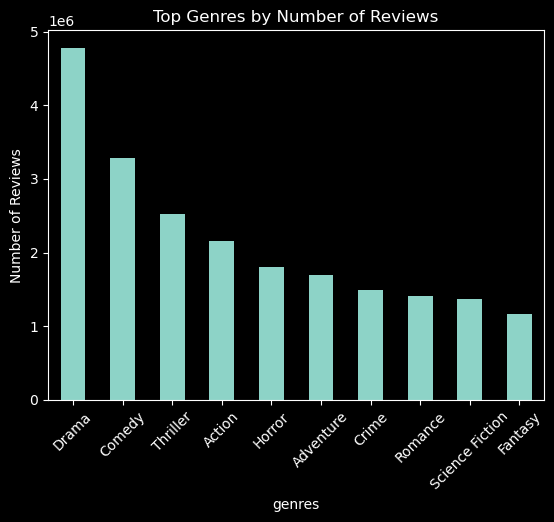

In [55]:
genre_counts.head(10).plot(kind='bar')
plt.style.use('dark_background')
plt.title("Top Genres by Number of Reviews")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45)
plt.show()

As seen in the graph, genres like Drama dominate the dataset in terms of number of reviews, indicating they are significantly more popular and receive much more user engagement than others.

### Hypothesis Testing: Relationship Between User Activity and Rating Behavior

To understand how user engagement relates to rating behavior, I investigated whether users with more reviews tend to rate movies differently. To be more specific, I tested whether there is a statistically significant relationship between the total number of reviews submitted by a user and that user’s average rating value.

These are both continuous numeric variables. A [Pearson correlation test](https://www.geeksforgeeks.org/maths/pearson-correlation-coefficient/) would measure the strength and direction of the linear relationship between them.

#### (1) Pearson Correlation

The hypotheses for the test were

$$ H_0: (ρ = 0) $$
$$ H_a: (ρ ≠ 0) $$
where 
$p$ represents the correlation coefficient,
$H_0$ means "There is no relationship between number of reviews and average rating," and
$H_a$ means "There is a significant relationship."

The Pearson correlation coefficient and p-value were computed using:

In [48]:
from scipy.stats import pearsonr

corr, p_val = pearsonr(user_ratings['num_reviews'], user_ratings['avg_rating'])

print("correlation:", corr)
print("p-value:", p_val)

correlation: -0.29052640542151426
p-value: 2.3268065050538835e-145


In [49]:
alpha = 0.05

if p_val < alpha:
    print("reject H0: significant relationship")
else:
    print("fail to reject H0: no significant relationship")

reject H0: significant relationship


The Pearson correlation value between number of reviews and average rating is -0.29, which indicates a slightly negative relationship. This suggests users who write more reviews tend to give slightly lower ratings on average.

The p-value is very small and far below the significance level of 0.05, so we reject the null hypothesis. This provides strong evidence that the relationship between user activity and rating behavior is statistically significant.

This result suggests that more active users may be more critical in their reviews compared to less active users.

To visualize this relationship I created the following scatter plot:

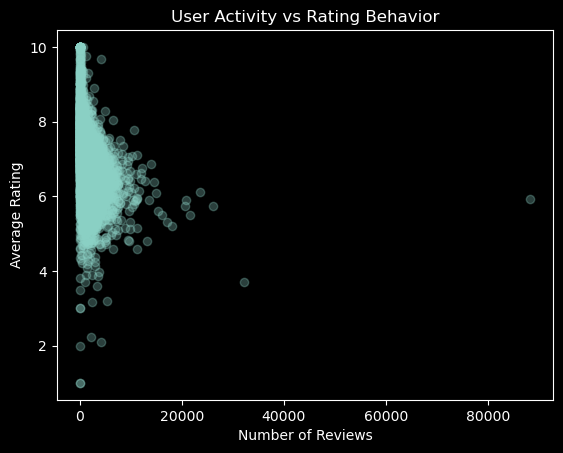

In [58]:
plt.scatter(user_ratings['num_reviews'],user_ratings['avg_rating'],alpha=0.3)
plt.style.use('dark_background')
plt.xlabel("Number of Reviews")
plt.ylabel("Average Rating")
plt.title("User Activity vs Rating Behavior")
plt.show()

One possible explanation for the slight downward trend in average rating is that users who watch and review more movies might become more critical over time, leading to slightly lower average ratings compared to less avid users. (I know this can happen....)

#### (2) Chi-Square Contingency Test

I also wanted to see whether users with different activity levels (number of reviews) preferred different movie genres. Specifically, I tested whether a user’s preferred genre is independent of how active they are on Letterboxd, in terms of number of reviews.

I needed disjoint "activity groups" for this, so users were divided into High Activity and Low Activity categories based on the median number of reviews submitted:

In [62]:
# divide users based on activity level: we will choose median for the split 
median_reviews = user_ratings['num_reviews'].median()
user_ratings['activity_level'] = user_ratings['num_reviews'].apply(lambda x: 'High' if x >= median_reviews else 'Low')

In [64]:
user_ratings.head(5)

,user_id,avg_rating,num_reviews,min_rating,max_rating,top_genre,activity_level,genre_diversity
0,007filmreviwer,6.637985,2243,1,10,Drama,High,19
1,007hertzrumble,6.855283,1997,1,10,Comedy,High,19
2,0o0o0o0o,6.290000,100,1,10,Drama,Low,18
3,11122001,6.120000,325,1,10,Thriller,Low,18
4,127gbh,6.954180,1615,1,10,Comedy,High,19


Users with review counts greater than or equal to the median went to the "High" group, while users below the median went to "Low."

The hypotheses for the test were:

$H_0$: Genre preference is independent of user activity level

$H_a$: Genre preference depends on user activity level

In this case, both variables (activity_level and top_genre) were categorical. So I used a [chi-squared test of independence](https://www.jmp.com/en/statistics-knowledge-portal/linear-models/chi-square-test/chi-square-test-of-independence) to determine whether a statistically significant relationship exists between them.

First I wanted to see the distribution of favorite genres across activity levels (High/Low):

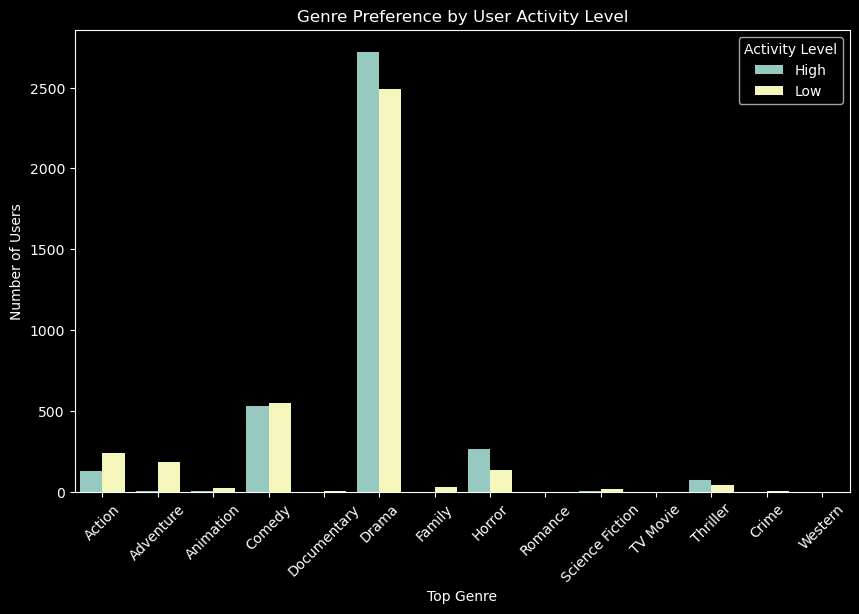

In [70]:
import seaborn as sns 

top_genre_dist = user_ratings.groupby(['activity_level','top_genre']).size().reset_index(name='count')

plt.figure(figsize=(10,6))
plt.style.use('dark_background')

sns.barplot(data=top_genre_dist,x='top_genre',y='count',hue='activity_level')

plt.xticks(rotation=45)
plt.title("Genre Preference by User Activity Level")
plt.xlabel("Top Genre")
plt.ylabel("Number of Users")
plt.legend(title="Activity Level")
plt.show()

The bar chart suggests some noticeable differences in genre preference between highly active and less active users. Certain genres (like Drama, Horror) appear more heavily represented among highly active users, and others (Action, Adventure) seem more favored by less active users, indicating that user engagement may influence viewing preferences.

Next, I created a contingency table and performed the chi-square test:

In [32]:
from scipy.stats import chi2_contingency

contingency = pd.crosstab(user_ratings['activity_level'],user_ratings['top_genre'])

vals = chi2_contingency(contingency)

chi = vals[0]
p_val = vals[1]
print("p-value:", p_val)

p-value: 3.922644461638506e-61


In [33]:
alpha = 0.05

if p_val < alpha:
    print("reject H0: significant relationship")
else:
    print("fail to reject H0: no significant relationship")

reject H0: significant relationship


As seen above, the resulting p-value is very small and far below the significance level of 0.05, so we reject the null hypothesis.

This indicates that genre preference is not independent of user activity level. This means users who write more reviews tend to prefer different genres compared to less active users. For example, users with a 'High' activity level may concentrate more in genres like Drama or Horror; users with a 'Low' activity level may have a different distribution of preferences.

One possible reason for this relationship is that highly active users develop more specialized viewing habits over time, thus causing them to concentrate more heavily in certain genres. Less active users might have broader/more spontaneous watch patterns. Overall, this analysis does suggest that user engagement is associated with distinct behavioral patterns in movie preference.

## Machine Learning Analysis

After completing exploratory analysis and hypothesis testing, the next goal of the project was to determine whether user rating behavior could be used to predict a user’s favorite movie genre. This was framed as a multi-class classification problem, where the model attempts to predict a user’s top_genre using features derived from their rating history and engagement behavior.

#### First: let's add some more features to user_ratings:

In [34]:
print(user_ratings.columns)

Index(['user_id', 'avg_rating', 'num_reviews', 'min_rating', 'max_rating',
       'top_genre', 'activity_level'],
      dtype='object')


This is what we have so far, but these features are not very descriptive when it comes to a user's broader viewing behavior. Let's add a couple features to the dataset so the model has more to work with. What would make sense for predicting a user's top genre? Let's think about their rating history...

First, I created a feature called genre_diversity, which is defined as the number of unique genres a user watches:

In [125]:
genre_diversity = (
    genre_ratings.groupby('user_id')['genres'].nunique()
    .reset_index(name='genre_diversity')
)
genre_diversity

,user_id,genre_diversity
0,007filmreviwer,19
1,007hertzrumble,19
2,0o0o0o0o,18
3,11122001,18
4,127gbh,19
...,...,...
7472,zwangsdemokrat,19
7473,zwergimbikini,19
7474,zxols,19
7475,zxvs,19


I then merged it into the existing user_ratings table so we have our features all together.

In [ ]:
# merge into user_ratings 
user_ratings = user_ratings.merge(genre_diversity,on='user_id',how='left')
# user_ratings
print(user_ratings.columns)
print(user_ratings.genre_diversity.isna().sum())

# drop x and y and verify, they are extra since we used a left join
user_ratings = user_ratings.drop(columns=['genre_diversity_x', 'genre_diversity_y'])
print(user_ratings.columns)

This feature will measure how broadly/narrowly a user engages with different types of movies. It is pretty intuitive: user who watches only Drama and Comedy movies would have lower genre diversity than a user who watches movies across many genres.

Next, I added rating_std, the standard deviation of each user’s ratings:

In [102]:
rating_std = (
    ratings.groupby('user_id')['rating_val'].std()
    .reset_index(name='rating_std')
)

user_ratings = user_ratings.merge(rating_std,on='user_id',how='inner')
print(user_ratings.columns)

Index(['user_id', 'avg_rating', 'num_reviews', 'min_rating', 'max_rating',
       'top_genre', 'activity_level', 'genre_diversity', 'rating_std'],
      dtype='object')


After mergin rating_std into the user-level DataFrame, the final feature set included:
- avg_rating
- num_reviews
- min_rating
- max_rating
- activity_level
- genre_diversity
- rating_std
  
I used these to predict top_genre (the target variable) which represents the genre each user rated most frequently. 

Because the dataset was heavily imbalanced toward Drama users, I decided to restrict the classification problem to the five most common genres:

In [114]:
# dataframe prep- checking class balance
user_ratings['top_genre'].value_counts()
# keep only top 5 genres 
top_genres = user_ratings['top_genre'].value_counts().head(5).index
top_genres

Index(['Drama', 'Comedy', 'Horror', 'Action', 'Adventure'], dtype='object', name='top_genre')

This reduced the impact of extremely small (in terms of user count) top_genre classes and made the prediction task more manageable.

I then populated the dataframe for machine learning with users whose top genre belonged to the top 5 genres, and the previously categorical activity_level feature was converted into binary numerical form to match the datatypes of the other numerical features.

In [106]:
ml_df = user_ratings[user_ratings['top_genre'].isin(top_genres)].copy()

# all columns of the above (besides user_id and top_genre) will be used as features 
# we have activity level already so let's turn it into binary encoding 
ml_df['activity_level'] = ml_df['activity_level'].map({'Low':0,'High':1})

# split dataset into x and y (trying to predict top genre)
X = ml_df[['avg_rating','num_reviews','min_rating','max_rating','activity_level','genre_diversity','rating_std']]
y = ml_df['top_genre']

The target labels (top_genre) were then encoded using LabelEncoder, which converts string labels into integer class labels. 

Now each of the 5 genres has a different integer assigned to it representing one of the 5 classifications the model could predict for each user!

In [107]:
# label encodings for class labels (5 predicted genres in output)
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_encoded

array([3, 2, 3, ..., 3, 3, 3])

The dataset was then divided into training and testing sets using an 80/20 split:

In [108]:
# train-test-split 
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

I used the stratify parameter to preserve the original class distribution in both the training and testing sets, which is especially important for imbalanced classification problems.

### Random Forest Classifier

To perform the classification task, I selected a Random Forest classifier.

A Random Forest is an ensemble learning method composed of many individual decision trees. Each tree is trained on a random subset of the data and learns a series of rules that split users based on feature values. 

Rather than relying on a single decision tree, the Random Forest combines predictions from many trees and selects the final prediction using majority voting (since this is a classification task). This improves accuracy and reduces overfitting compared to using a single tree alone.

Random Forests would be useful here because:
1. They can model nonlinear relationships between behavioral features and genre preference.
2. They do not require feature scaling/normalization, which is useful since each feature has pretty different scales.
3. They are interpretable and provide feature importance scores, which are useful for understanding which user behaviors most strongly influence predictions.

The classifier was initialized as follows:

In [111]:
# train a random forest classifier to predict genre 
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

# train model on training data
model.fit(X_train, y_train)

# predictions
preds = model.predict(X_test)

The parameter n_estimators=200 specifies that the forest should contain 200 decision trees. I included the class_weight='balanced' option to try to compensate for the substantial class imbalance in the dataset by assigning greater importance to underrepresented genres (classes) during training.

Now that our model is trained and we have predictions on the test set, let's evaluate the predictions!

## Evaluation and Visualizations

In [115]:
# evaluate using accuracy
from sklearn.metrics import (
    accuracy_score,
    classification_report
)

print(f"accuracy: {accuracy_score(y_test, preds)}")

print(classification_report(
    y_test,
    preds,
    target_names=le.classes_ # get class names back from labelencoder
))

accuracy: 0.70474879559532
              precision    recall  f1-score   support

      Action       0.33      0.01      0.03        74
   Adventure       0.00      0.00      0.00        39
      Comedy       0.18      0.02      0.04       216
       Drama       0.72      0.98      0.83      1043
      Horror       0.50      0.01      0.02        81

    accuracy                           0.70      1453
   macro avg       0.35      0.20      0.18      1453
weighted avg       0.59      0.70      0.60      1453



The model was evaluated using sklearn's classification report, which gives accuracy and per-class precision, recall, and F1-score.

The classifier achieved a reasonably strong overall accuracy (0.71), but performance was extremely uneven across genres. The classification report showed that the model performed extremely well on predicting the Drama class, with:

- Precision: 0.72
- Recall: 0.98 
- F1-score: 0.83

The recall score is especially remarkable: 0.98 means 98% of true Drama-preferring users were correctly identified, meaning the model learned strong Drama-associated patterns!

But the remaining genre performance was substantially worse. Adventure, Action, and Horror had recall scores of nearly zero, so the model almost never identified these preferences correctly. Users that belonged to those classes were instead usually predicted as preferring Drama. 

This behavior becomes more apparent in the confusion matrix visualization:

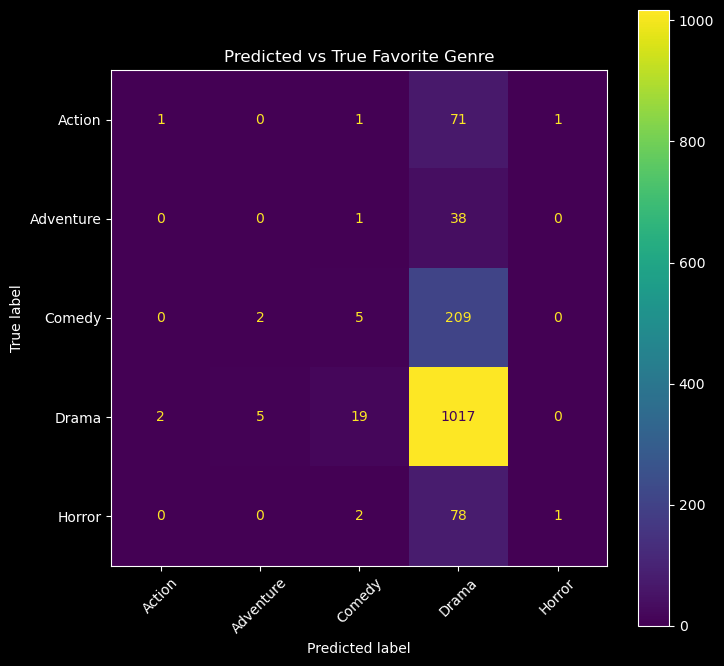

In [122]:
# not great... let's see which genres the model confuses 
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,8))
plt.style.use('dark_background')

ConfusionMatrixDisplay.from_estimator(
    model,
    X_test,
    y_test,
    display_labels=le.classes_,
    xticks_rotation=45,
    ax=ax
)

plt.title("Predicted vs True Favorite Genre")
plt.show()

The confusion matrix shows how the classifier strongly favors the Drama class, and correctly identified Drama users with high accuracy but frequently misclassified smaller genres (Comedy, Horror, Action) as Drama. This is likely due to substantial class imbalance in the dataset: Drama-preferring users greatly outnumbered other genre preferences. 

So although the model achieved decent overall accuracy, the confusion matrix demonstrates that this is largely driven by predictions for the dominant class rather than balanced performance across all genres. The classifier learned that predicting Drama minimized overall classification error. This is an important limitation of classification models trained on imbalanced datasets.

#### Feature Importance Analysis 

One advantage of using a Random Forest classifier is that it provides [feature importance](https://www.geeksforgeeks.org/machine-learning/understanding-feature-importance-and-visualization-of-tree-models/) scores, which estimate how much each feature contributed to the model’s predictions.

In a Random Forest, each decision tree repeatedly selects features that best split the training data into different classes. Features that consistently improve decision splits across many trees receive higher importance scores. In our case, feature importance gives us insight into which aspects of user behavior were most useful for predicting favorite genre.

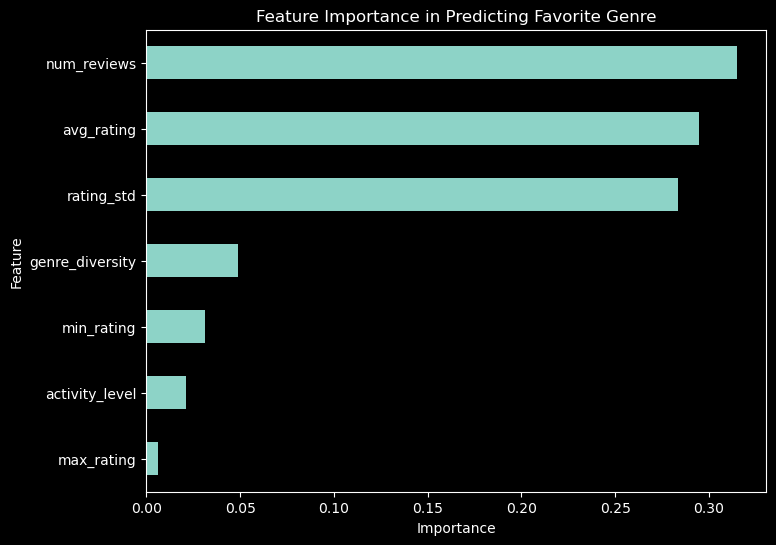

In [123]:
# visualize feature importance: which features contributed most 
# to predictions? 
importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
})

plt.style.use('dark_background')

# sort by ascending so we see most important 
importance = importance.sort_values('importance',ascending=True)

importance.plot(
    kind='barh',
    x='feature',
    y='importance',
    figsize=(8,6),
    legend=False
)

plt.title("Feature Importance in Predicting Favorite Genre")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

This graph indicates that the most influential predictors of favorite genre were (per user) number of reviews, average rating, and rating variability. This suggests that long-term user behavior was more informative for predicting genre preference than any single rating: min and max ratings contributed very little to the model, implying that users’ occasional "extreme" scores were not strongly associated with genre preference. The activity level feature was least important, which likely because the number of reviews generally captured most of the same information.

Overall, the feature importance analysis suggests that broad behavioral patterns (measured by num_reviews, avg_rating, rating_std) contain meaningful information about movie preference. However, the model's weak performance on minority genres shows that these behavioral patterns alone are not sufficient to fully distinguish genre preferences. Better and more detailed features like review text or movie-specific (favorite movie) preferences, would likely improve predictions.

## Conclusions 

<table cellspacing="0" cellpadding="0" border="0">
  <tr>
    <td style="text-align: center;">
      <img src="img/pierrot_le_fou.gif" alt="GIF 1" width="300" />
    </td>
    <td style="text-align: center;">
      <img src="img/good-time-robert-pattinson.gif" alt="GIF 2" width="300" />
    </td>
    <td style="text-align: center;">
      <img src="img/chungking-express.gif" alt="GIF 3" width="300" />
    </td>
    <td style="text-align: center;">
      <img src="img/enter_the_void.gif" alt="GIF 4" width="300" />
    </td>
  </tr>
</table>

This project began with a fairly simple question: what can Letterboxd rating behavior tell us about movie preferences? Letterboxd users do not only watch movies, but also rate, organize, and publicly display their taste. This makes the platform a useful window into how people engage with film. Through exploratory analysis, hypothesis testing, and the final machine learning analysis I found that user behavior does reveal meaningful patterns; but also, movie taste is pretty difficult to predict from ratings data alone.



Here were my major findings:
1. Genre preference patterns were highly uneven. Drama received the most reviews by far and dominated the dataset in terms of user activity. This could reflect the broadness of Drama as a category, since many films across different styles and subjects can be considered Drama... it may also suggest that users on Letterboxd tend to engage more heavily with serious/narrative-driven/more critically discussed films. However, this was an important challenge for the later machine learning analysis: since Drama was so overrepresented, the model became biased in its predictions.

2. User activity is related to rating behavior. The Pearson correlation test showed a statistically significant negative relationship between number of reviews and average rating. In other words, users who reviewed more movies tended to give slightly lower ratings on average: perhaps more active users become more critical/selective in how they evaluate films. The chi-square test also showed that genre preference depends on user activity level, and that high-activity and low-activity users did not have the same distribution of favorite genres. This suggests that the more users engage with the platform, the more their viewing habits might begin to cluster around certain types of films. 

The machine learning model gave mixed results; allthough the Random Forest classifier reached about 70% accuracy, the confusion matrix showed that this was a misleading score. The model predicted Drama well but very poorly on the other, less common genres (Adventure, Horror, Action, Comedy). This is an important consideration for future analysis: accuracy alone is not enough when the dataset is imbalanced.


Overall, this project shows that while Letterboxd rating data can reveal meaningful patterns in user behavior, there are limits involved in reducing taste to numbers. Genre preferences are shaped by many factors that cannot be fully captured by rating history: personal experiences, mood, cultural background, aesthetics, favorite directors/actors, social significance... even how a person understands the act of "rating." A five-star rating scale and a genre label can tell us something, but they cannot fully explain why a film might matter to someone.

In future work, this analysis could be improved by adding richer features such as review text, favorite actors or directors, release decade preferences, movie popularity, or the order in which users watched films. Text analysis of written reviews would be especially useful as it could capture tone, emotion, and reasoning that numerical ratings don't. With these additional features, a model might be able to better distinguish between users whose rating patterns look similar numerically, but whose actual tastes are very different.